# 04. Model Interpretation with SHAP

03번 노트북에서 최종 모델이 Batch 2의 거의 모든 셀을 실제보다 길게 예측했습니다(평균 +26%). 이 노트북은 **그 편향이 어느 피처에서 왔는지** SHAP으로 분해합니다. 02번 노트북에서 세운 가설, 즉 "배치마다 값 범위가 다른 초기 용량 피처(`QD_2`, `QD_max_minus_2`)가 Batch 2의 과대예측과 관련 있을 수 있다"를 확인하는 것이 목적입니다.

- **사후 진단입니다.** 최종 모델은 그대로 두고 이미 나온 예측을 설명할 뿐이며, 모델 선택이나 재학습에는 쓰지 않습니다. Test 라벨을 사용하지만 어떤 모델도 바꾸지 않습니다.
- **SHAP이 말해 주는 것은 "모델이 어떤 피처에 얼마나 반응했나"까지입니다.** 실제 물리적 원인을 증명하지는 않습니다.

구성: 1. SHAP 계산 → 2. 모델이 의존하는 피처 → 3. Batch 2 편향의 출처 → 4. 셀 단위 설명 → 5. 정리

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # 저장소 루트를 경로에 추가 (src/ 임포트용)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# 그래프 공통 스타일 (그림 안 글자는 폰트 의존을 피하려고 영문으로 작성)
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().parent                         # 저장소 루트
FIG = ROOT / "results" / "figures"               # 그림 저장 위치

## 1. SHAP 계산

최종 모델(D6 피처셋 + ElasticNet)을 Batch 1 전체로 학습하고, Batch 1·2·3 각 셀의 예측을 피처별 기여로 나눕니다. 배경(기준점)은 학습 데이터인 Batch 1의 평균입니다.

기여도의 단위는 `log10(cycle_life)`입니다. 예를 들어 기여도 +0.046은 수명을 `10^0.046 − 1 ≈ 11%` 늘리는 방향으로 작용했다는 뜻입니다. 선형 모델이라 SHAP 값은 `표준화 계수 × (값 − 평균)`과 정확히 같고, 코드에서 `shap.LinearExplainer`의 결과와 일치하는지 검증합니다.

In [2]:
from src.train import load_data
from src.interpret import fit_final, shap_table

df = load_data(ROOT / "data")
b1 = df[df.batch == 1].reset_index(drop=True)

model, cols, _ = fit_final(b1)                       # 03번 노트북의 최종 모델과 같은 절차
S = {}                                               # 배치별 SHAP 표
for b in (1, 2, 3):
    t = df[df.batch == b].dropna(subset=cols).reset_index(drop=True)
    S[b] = shap_table(model, cols, b1, t).assign(true_log=t.log_life.values)

DQ = ["dq_log_var", "dq_log_abs_min", "dq_skew", "dq_kurt"]      # ΔQ 곡선 피처
QD = ["QD_2", "QD_max_minus_2"]                                  # 초기 용량 피처
print("피처:", cols)
print("표준화 계수:", dict(zip(cols, model.steps[-1][1].coef_.round(3))))

피처: ['dq_log_var', 'dq_log_abs_min', 'dq_skew', 'dq_kurt', 'QD_2', 'QD_max_minus_2']
표준화 계수: {'dq_log_var': np.float64(-0.045), 'dq_log_abs_min': np.float64(-0.048), 'dq_skew': np.float64(0.004), 'dq_kurt': np.float64(-0.008), 'QD_2': np.float64(0.025), 'QD_max_minus_2': np.float64(-0.024)}


계수만 보면 `dq_log_var`와 `dq_log_abs_min`이 가장 크고(약 −0.045, −0.048), 초기 용량 피처는 절반 정도입니다. 다만 SHAP은 계수에 **그 셀의 값이 평균에서 얼마나 떨어져 있는지**를 곱하므로, 값이 학습 범위 밖으로 나가는 배치에서는 계수가 작은 피처도 기여가 커질 수 있습니다.

## 2. 모델이 의존하는 피처

배치별 평균 절대 기여도(mean |SHAP|)를 비교합니다. 값이 클수록 그 피처가 예측을 많이 움직였다는 뜻입니다. 셀별 분포는 바로 아래 점 그래프에서 봅니다.

In [3]:
imp = pd.DataFrame({f"Batch {b}": S[b][cols].abs().mean() for b in S})
display(imp)
display((imp["Batch 2"] / imp["Batch 1"]).rename("B2 / B1 배율").to_frame())

,Batch 1,Batch 2,Batch 3
dq_log_var,0.037,0.079,0.076
dq_log_abs_min,0.039,0.083,0.083
dq_skew,0.003,0.006,0.003
dq_kurt,0.006,0.020,0.018
QD_2,0.018,0.051,0.043
QD_max_minus_2,0.019,0.064,0.026


,B2 / B1 배율
dq_log_var,2.159
dq_log_abs_min,2.128
dq_skew,1.998
dq_kurt,3.425
QD_2,2.797
QD_max_minus_2,3.386


Batch 1(학습)에서는 ΔQ 계열(`dq_log_var`, `dq_log_abs_min`)이 가장 크게 작용해, Day 1에서 세운 "ΔQ 중심" 전략이 실제 모델에서도 지켜졌음을 확인할 수 있습니다. 초기 용량 피처(`QD_2`, `QD_max_minus_2`)는 그 절반 수준입니다.

Batch 2에서는 모든 피처의 영향이 커지는데, **초기 용량 피처가 ΔQ 분산·최솟값보다 더 크게 늘어납니다**(`QD_max_minus_2`는 약 3.4배, `QD_2`는 약 2.8배, `dq_log_var`는 약 2.2배, `dq_kurt`도 3.4배지만 기여의 절대값은 작습니다). Batch 2 셀의 이 값들이 학습 범위를 벗어나 평균에서 멀리 떨어져 있기 때문이며, 02번 노트북의 값 범위 점검과 같은 신호입니다. 다만 영향이 커졌다는 것과 편향을 만들었다는 것은 다른 이야기라서 다음 절에서 방향까지 확인합니다.

### 피처별 기여 분포

위 표는 평균만 보여 주므로, 셀마다 기여가 어떻게 흩어지는지는 SHAP의 기본 요약 그래프(beeswarm)로 봅니다. 점 하나가 셀 하나이고, 가로 위치가 그 피처가 예측을 얼마나 올리거나(오른쪽) 내렸는지(왼쪽), 색이 그 셀의 피처 값(빨강이 높음, 파랑이 낮음)입니다. 두 그림의 가로축을 같게 맞췄습니다.

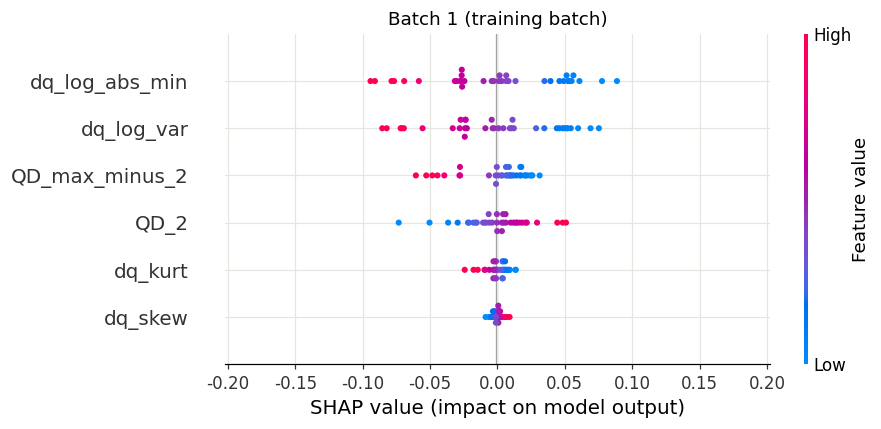

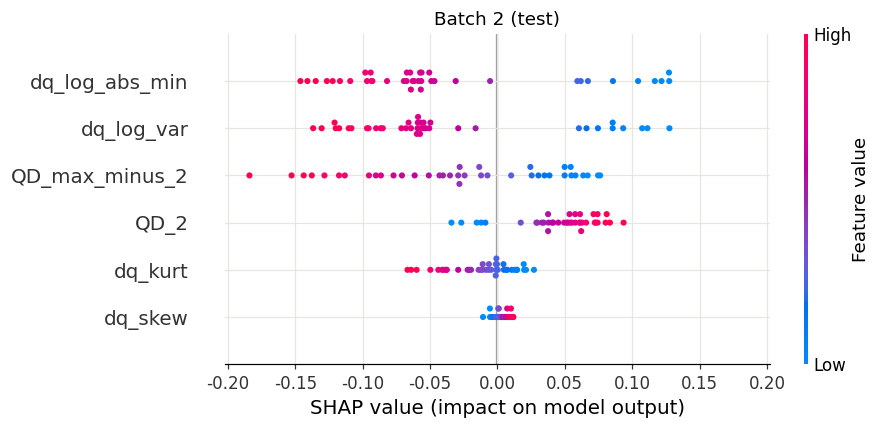

In [4]:
import shap

X = {b: df[df.batch == b].dropna(subset=cols).reset_index(drop=True) for b in (1, 2)}      # 피처 원래 값 (색 표시용)

def explanation(b):
    return shap.Explanation(values=S[b][cols].values, base_values=S[b].base.values,
                            data=X[b][cols].values, feature_names=cols)

lim = max(np.abs(S[b][cols].values).max() for b in (1, 2)) * 1.1             # 두 배치의 가로축을 통일
for b, name in [(1, "Batch 1 (training batch)"), (2, "Batch 2 (test)")]:
    shap.plots.beeswarm(explanation(b), max_display=len(cols), show=False)
    plt.title(name); plt.xlim(-lim, lim)
    plt.gcf().savefig(FIG / f"shap_beeswarm_b{b}.png", dpi=180, bbox_inches="tight"); plt.show()

**Batch 1.** `dq_log_abs_min`과 `dq_log_var`는 값이 낮을수록(파랑) 오른쪽, 즉 수명을 길게, 높을수록(빨강) 왼쪽으로 밀어 줍니다. "ΔQ 변화가 클수록 단수명"이라는 EDA의 방향과 같습니다.

**Batch 2.** 같은 방향이지만 점이 훨씬 넓게 퍼집니다(가로 ±0.15 안팎, Batch 1은 ±0.09 안팎). 학습 범위를 벗어난 값이 많기 때문입니다. 눈에 띄는 것은 `QD_2`로, 점 대부분이 오른쪽(수명을 늘리는 쪽)에 몰려 있습니다. Batch 2의 39셀 중 34셀이 Batch 1 평균보다 `QD_2`가 높고 모델은 이를 "수명이 길다"는 신호로 읽는데, Batch 2에서는 `QD_2`와 수명의 상관이 오히려 음수(−0.20)입니다. `QD_max_minus_2`는 반대로 왼쪽으로 크게 밀려(최대 약 −0.18) 일부를 상쇄합니다.

## 3. Batch 2 편향의 출처

평균적으로 모델이 예측한 수명이 학습 평균에서 얼마나 움직였는지(예측 이동)를 피처 그룹별 기여로 나누고, 실제 수명이 움직인 양(실제 이동)과 비교합니다. 예측 이동이 실제 이동보다 크면 그만큼이 과대예측입니다.

In [5]:
rows = []
for b in (2, 3):
    s = S[b]; base = s.base.iloc[0]
    pred_shift, true_shift = s.pred_log.mean() - base, s.true_log.mean() - base
    bias = (s.pred_log - s.true_log).mean()                       # 평균 과대예측 (log10)
    bias_wo_qd = (s.pred_log - s[QD].sum(axis=1) - s.true_log).mean()   # 초기 용량 기여를 0 으로 둔 경우
    rows.append({"배치": f"Batch {b}", "ΔQ 피처 기여": s[DQ].mean().sum(), "초기용량 피처 기여": s[QD].mean().sum(),
                 "예측 이동": pred_shift, "실제 이동": true_shift, "편향(예측−실제)": bias,
                 "편향, 초기용량 기여 제거 시": bias_wo_qd,
                 "편향 %": (10 ** bias - 1) * 100, "초기용량 제거 시 편향 %": (10 ** bias_wo_qd - 1) * 100})
summary = pd.DataFrame(rows).set_index("배치")
display(summary.T)

배치,Batch 2,Batch 3
ΔQ 피처 기여,-0.084,0.129
초기용량 피처 기여,0.019,-0.018
예측 이동,-0.065,0.111
실제 이동,-0.162,0.108
편향(예측−실제),0.097,0.003
"편향, 초기용량 기여 제거 시",0.078,0.021
편향 %,24.882,0.707
초기용량 제거 시 편향 %,19.578,4.892


**Batch 2.** 실제 수명은 학습 평균보다 로그 기준 약 0.16 짧아졌는데, 모델의 예측은 약 0.065만 내려갔습니다. 예측 이동의 대부분은 ΔQ 피처가 만들었고(약 −0.084, 방향은 맞음), 초기 용량 피처는 합쳐서 오히려 +0.02 쪽으로 밀었습니다. `QD_2`는 +0.05 정도로 예측을 끌어올렸고 `QD_max_minus_2`는 −0.03 정도로 끌어내려 일부가 상쇄됩니다.

중요한 점은 **초기 용량 기여를 0으로 두어도 평균 편향이 +25%에서 +20% 정도로만 줄어든다**는 것입니다. 편향의 약 5분의 1만 초기 용량 피처에서 왔고, 나머지는 ΔQ 피처가 실제만큼 수명을 낮추지 못한 데서 옵니다. 02번 노트북에서 세운 가설은 **일부만 맞았습니다.**

**Batch 3.** 예측 이동(약 +0.11)이 실제 이동(약 +0.11)과 거의 같고 편향이 거의 없습니다. 같은 모델의 ΔQ 피처가 Batch 3에서는 수명 변화를 제대로 따라갔다는 뜻입니다. 이 대비가 Batch 2의 문제를 더 분명히 합니다.

## 4. 셀 단위 설명

Force plot은 셀 하나의 예측이 **기준값에서 출발해 어떤 피처에 의해 얼마나 밀렸는지**를 보여 줍니다. 기준값은 학습 데이터(Batch 1)의 평균 예측이고, 빨강은 수명을 길게, 파랑은 짧게 미는 힘입니다. 가장 크게 틀린 Batch 2 셀과 가장 잘 맞힌 Batch 2 셀을 나란히 봅니다.

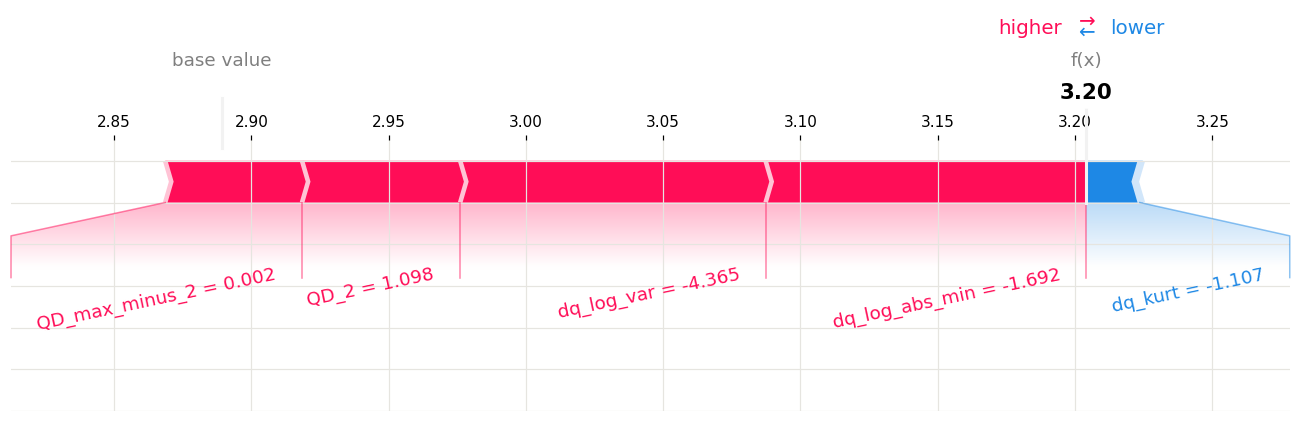

b2c44 (worst): 실제 수명 841 → 예측 1600 (오차 90%), 기준값 775


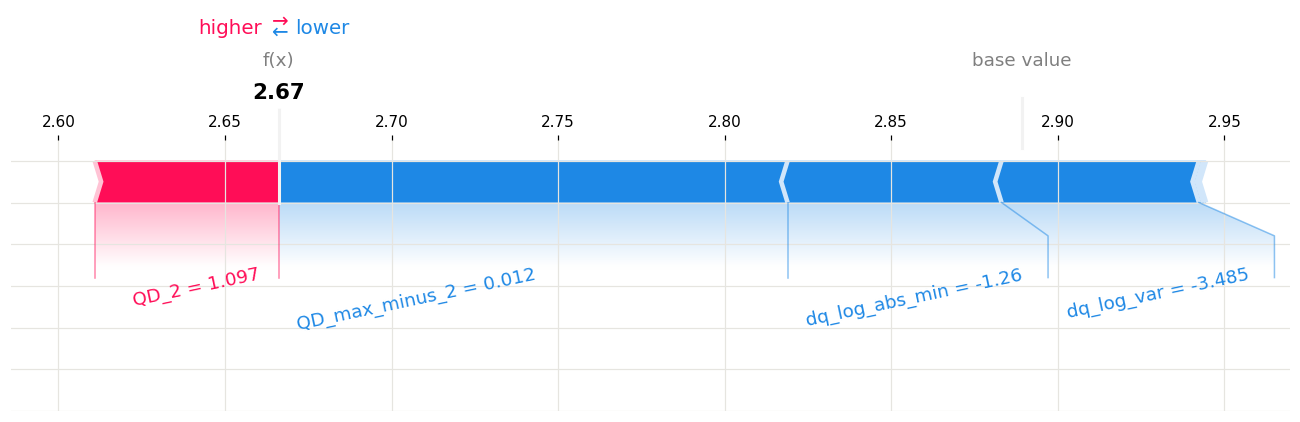

b2c11 (best): 실제 수명 449 → 예측 464 (오차 3%), 기준값 775


In [6]:
s2 = S[2].assign(ape=lambda d: (10 ** d.pred_log - 10 ** d.true_log).abs() / 10 ** d.true_log * 100)
picks = {"worst": s2.ape.idxmax(), "best": s2.ape.idxmin()}                  # Batch 2 에서 오차가 가장 큰 셀과 가장 작은 셀

for tag, cid in picks.items():
    i = list(S[2].index).index(cid)
    shap.force_plot(S[2].base.iloc[i], S[2][cols].values[i], X[2][cols].values[i].round(3), feature_names=cols,
                    matplotlib=True, show=False, figsize=(15, 3.2), text_rotation=12)
    plt.gcf().savefig(FIG / f"shap_force_b2_{tag}.png", dpi=180, bbox_inches="tight"); plt.show()
    r = s2.loc[cid]
    print(f"{cid} ({tag}): 실제 수명 {10 ** r.true_log:.0f} → 예측 {10 ** r.pred_log:.0f} (오차 {r.ape:.0f}%), 기준값 {10 ** r.base:.0f}")

**가장 크게 틀린 셀 `b2c44`** (실제 841 → 예측 1,600, `-newstructure`). `dq_log_var`(−4.36)와 `dq_log_abs_min`(−1.69)이 둘 다 Batch 1의 최저값(−4.18, −1.63)보다도 낮아서, 모델이 "ΔQ 변화가 아주 작으니 수명이 아주 길다"고 읽고 기준값(775)에서 크게 끌어올렸습니다. 학습 범위 밖의 ΔQ 값을 선형으로 그대로 연장한 결과이고, 이 셀의 실제 수명은 그만큼 길지 않았습니다. `QD_2`, `QD_max_minus_2`도 같은 방향으로 밀었습니다.

**가장 잘 맞힌 셀 `b2c11`** (실제 449 → 예측 464). 피처 값이 모두 Batch 1 범위 안에 있고, ΔQ 피처가 예측을 기준값 아래로 정상적으로 끌어내렸습니다. 학습 범위 안에서는 모델이 의도대로 작동한다는 뜻입니다.

두 셀을 비교하면 오차의 큰 부분이 모델 구조보다 **학습 범위 밖의 ΔQ 값에서 나온다**는 점이 분명해집니다.

## 5. 정리

- **편향의 대부분은 초기 용량 피처가 아니라 ΔQ와 수명 관계의 배치 간 차이에서 옵니다.** 초기 용량 피처의 기여를 제거해도 Batch 2 편향은 +25%에서 +20% 정도로만 줄었습니다. 02번 노트북의 가설(초기 용량 피처가 주원인)은 부분적으로만 지지됩니다.
- **초기 용량 피처는 개별 셀의 오차를 키우는 노이즈 요인입니다.** Batch 2에서 이 피처들의 영향이 2∼3배로 커지고 `QD_2`와 `QD_max_minus_2`가 서로 반대 방향으로 작용해, 평균은 상쇄되어도 셀마다 예측이 흔들립니다.
- **Batch 3에서는 같은 모델이 잘 맞습니다.** Batch 2만의 문제라는 점에서 모델 구조보다 배치(제조 로트 등)의 특성에 가까워 보이지만, 이 노트북으로 원인이 확정되지는 않습니다.
- **시사점.** 새 배치에서는 소수 셀의 실측 수명으로 ΔQ와 수명의 관계를 재보정하는 방법이 피처를 더하거나 빼는 것보다 효과적일 가능성이 큽니다. 다만 이 제안은 Test를 본 뒤에 나온 것이라 검증하지 않았습니다.
- **한계.** 피처 6개가 서로 상관되어 있어 기여가 피처 사이에 나뉘어 나올 수 있고, 셀 수가 적어 평균값의 불확실성이 큽니다. 위 수치는 이 모델과 이 데이터에 대한 설명이며 일반 법칙이 아닙니다.